## Problem 1

The SinusoidalEmbedding in the lecture notebook and textbook implement are the same with minor framework-specific differences. Both use log-spaced frequencies between 1 and 1000 and generate a 32-dimensional embedding by applying sine and cosine functions to 16 frequencies and concatenating the results. The primary difference is tensor layout: the lecture (PyTorch) version returns a tensor shaped as channels-first (B × 32 × 1 × 1), while the textbook (Keras) version concatenates along the channel axis (axis=3 in NHWC format). Functionally, they are equivalent.

The purpose of this embedding is to convert scalar noise variance into a 32-dimensional representation. Instead of passing a single scalar value to the network, the sinusoidal embedding maps it into a vector. This allows the network to distinguish different noise levels smoothly and continuously, so it can learn different denoising behaviors at different stages of the diffusion process.

Concatenating the embedding vector with the initial convolution output allows the entire U-Net is to be conditioned on the current noise level. Without this conditioning, the CNN would use a single denoising function for all timesteps. While not mathematically required, some form of timestep conditioning is practically essential for diffusion models to work; removing it without replacement would likely cause the model to fail or perform very poorly.

The 32-dimensional size (16 frequencies × sin/cos pairs) provides a compact multi-scale representation. Log-spaced frequencies are used so that both small and large changes in timestep can be represented smoothly. Low frequencies capture coarse variation across timesteps, while high frequencies allow the model to differentiate nearby timesteps more precisely. This improves stability and expressiveness without adding a lot of extra computational cost.


### Forward method
For each of the classes discussed here and in the answers below, the lecture version defines a `forward()` method that is not in the textbook. This is just a framework difference and does not impact the functionality of these classes. PyTorch requires every `nn.Module` to explicitly define how inputs pass through the layer. In the Keras functional API (textbook) execution is handled through functional composition so a callable function is returned and no `forward()` method is needed. This is simply a difference between PyTorch and Keras and does not impact what the classes do in both UNets.



## Problem 2

The ResidualBlock implementations in the lecture notebook and textbook share the same fundamental design: two 3×3 convolutional layers in the main path combined with a skip (residual) connection. If the input and output channel dimensions match, the skip connection is an identity mapping. Otherwise, it's a 1×1 convolution used to project the input to the correct number of channels. Functionally, both versions implement the same residual learning from ResNets.

Key differences:

- The lecture version applies BatchNorm after each convolution (conv → BN → SiLU for the first layer, conv → BN before addition for the second). The textbook version applies BatchNorm once before the first convolution and does not include BatchNorm after the second convolution.
- In the lecture version, SiLU (Swish) is applied after the first convolution and again after the residual addition. In the textbook version, the activation is included in the first convolution layer and no activation is applied after the residual addition.
- For the BN parameters, the textbook uses center=False while the textbook uses PyTorch BatchNorm2d.

Despite these structural differences, both blocks perform the same operation of learning a residual correction to the input feature map.

A residual block is a group of layers that contains a skip connection that adds the input to the output. Residual blocks help networks learn complex patterns without suffering as greatly from vanishing gradient and degradation problems. The vanishing gradient problem is the assertion that as the network gets deeper, the gradient propagated through deeper layers is tiny and therefore learning is very slow. Degradation is what happens as neural networks become deeper, they are not necessarily as accurate as their shallower counterparts and they become saturated at a certain depth and then degrade rapidly.


In both the lecture and textbook there are 14 residual blocks in total:

- 3 DownBlocks × 2 = 6 ResidualBlocks
- Middle: 2 ResidualBlocks
- 3 UpBlocks × 2 = 6 ResidualBlocks

## Problem 3

The Sigmoid activation function is:

\begin{equation}
    \sigma(x) = \frac{1}{1+e^{-x}}.
\end{equation}

It has an output range of (0,1) and, as such, turns inputs into probability values. 

The SiLU is:

\begin{equation}
    \text{SiLU}(x) = x \cdot \sigma (x).
\end{equation}


It multiplies the input by its sigmoid and has an output range of $(-\infty,\infty)$.  It preserves magnitude and sign information which improves gradient flow and is why it's more suitable for networks such as U-Nets. SiLU is sometimes called Swish.

The purpose of the SiLU activation layer is to introduce nonlinearity so the network can model complex, nonlinear relationships such as separating noise from signal in diffusion models. It improves gradient flow compared to sigmoid by avoiding strong saturation and preserving magnitude information, which helps stabilize the network. Additionally, SiLU allows the model to smoothly control how much feature information passes through each residual block.

### Reference
Ultralytics. (n.d.). SiLU (Sigmoid Linear Unit). Ultralytics Glossary. Retrieved March 1, 2026, from https://www.ultralytics.com/glossary/silu-sigmoid-linear-unit

## Problem 4

The bottleneck layers in a U-Net capture highly compressed, global feature representations at the lowest spatial resolution, allowing the network to integrate context before the decoder reconstructs details using skip connections.

Without the bottleneck:
- The model would rely only on local features.
- Long-range dependencies would be harder to capture.
- Generated or reconstructed images would lack global consistency.

The bottleneck ensures the network understands overall image structure before reconstruction begins.

### Reference
Ultralytics. (n.d.). A guide on U-Net architecture and its applications. Ultralytics Blog. Retrieved March 1, 2026, from https://www.ultralytics.com/blog/a-guide-on-u-net-architecture-and-its-applications

## Problem 5
The DownBlock in both the lecture notebook and the textbook perform the same function: extracting features while reducing resolution and storing intermediate activations for skip connections. Conceptually, they match.

In both versions:

- Multiple ResidualBlocks are applied sequentially at the same spatial resolution.
- After each residual block, the activation is appended to a skip list for later use.
- The spatial resolution is reduced using pooling: `AveragePooling2D` in the textbook and `AvgPool2d` in the lecture version

The differences are all framework-related:
- In the lecture (PyTorch) implementation, the `forward()` method explicitly receives and updates a skips list.
0 In the textbook (Keras functional API), the DownBlock receives a tuple `(x, skips)` and returns the updated tensor.
- Tensor layout differs (channels-first in PyTorch vs channels-last in Keras), but functionality is equivalent.




## Problem 6

The UpBlock implementations in the lecture notebook and the textbook match conceptually, and just differ in framework syntax (PyTorch vs. Keras). In both versions, the UpBlock:

- Upsamples the feature map to increase spatial resolution.
- Retrieves stored skip features from the encoder.
- Concatenates the upsampled tensor with the corresponding skip tensor.
- Applies multiple ResidualBlocks to refine the combined features.

In the lecture (PyTorch) version, the UpBlock explicitly pops tensors from a stack inside the `forward()` method. In the textbook, (Keras API) version, the skip list is passed and updated within a returned function. This is the same framework difference I discuss in the answer to question 1. They are functionally equivalent.

The UpBlock performs the decoder-stage reconstruction of the image.

It does three main things:
- Upsamples to doubles the height and width of the feature maps, reversing the compression introduced during downsampling.
- Concatenates skip features which restores resolution information lost during downsampling into a concatenated tensor.
- Process the concatenated tensor, integrating global representations from the bottleneck with local information from earlier layers.

This process reconstructs image structure from more abstract and compressed representations.

 Skip connections allow data to bypass one or more layers and flow directly to subsequent processing stages. They directly pass feature maps from encoder layers to decoder layers; this forms a “U” shape for the architecture. Skip connections preserve spatial information lost during downsampling and improve gradient flow which enables better reconstructions and more stable training.

Without skip connections:
- Outputs may become blurry.
- Fine details are difficult to reconstruct.
- Training becomes less stable.

### Reference
Ultralytics. (n.d.). Residual Networks (ResNet). Ultralytics Glossary. Retrieved March 1, 2026, from https://www.ultralytics.com/glossary/residual-networks-resnet

## Problem 7

In denoising diffusion probabilistic models (DDPMs), a diffusion schedule defines how noise is gradually added to data during the forward process and how it is removed during the reverse process. It specifies a sequence of noise levels or continuous-time noise rates that control how much signal is retained and how much noise is injected at each timestep. It controls the rate at which signal-to-noise ratio decreases which makes the transition from structured images to pure noise smoother. By distributing learning difficulty across timesteps, it stabilizes gradients and improves sample quality. Without an appropriate diffusion schedule, training can become unstable or inefficient, and the model may struggle to learn accurate denoising at different noise levels.

### Reference
Guo, Z., Lang, J., Huang, S., Gao, Y., & Ding, X. (2025). A comprehensive review on noise control of diffusion model. arXiv. https://arxiv.org/abs/2502.04669v1

## Problem 9

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 72
import numpy as np
import sys

import torch
from torch import nn, optim
import torchvision

print(f'PyTorch version= {torch.__version__}')
print(f'torchvision version= {torchvision.__version__}')
print(f'CUDA available= {torch.cuda.is_available()}')

# set the GPU to device 0
Device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():  # CUDNN Installation
    print(f'Available devices: {torch.cuda.device_count()}, Name: {torch.cuda.get_device_name(0)}')

PyTorch version= 2.10.0
torchvision version= 0.25.0
CUDA available= False


In [2]:
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision.datasets as dset
import torchvision.transforms as vtransforms

IMG_CHANNEL= 1  # based on the dataset
IMG_SIZE= 32  # image size, square

BATCH_SIZE= 3096

N_REPEAT= 2  # per textbook, 5 for flowers dataset

# found the following from studies
means_flowers102, stdevs_flowers102 = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
means_mnist, stdevs_mnist = (0.1307), (0.3081)

# use the correct one
# means_data, stdevs_data = means_flowers102, stdevs_flowers102
means_data, stdevs_data = means_mnist, stdevs_mnist

# dif_ds_ = dset.Flowers102(root = "/EP_datasets/flowers102", download=False, split='train',
dif_ds_ = dset.MNIST(root = "EP_datasets/mnist", download=False, train=True,
                     transform=vtransforms.Compose([
                       vtransforms.Resize([IMG_SIZE,IMG_SIZE], antialias=True),
                       vtransforms.ToTensor(),
                       vtransforms.Normalize(means_data, stdevs_data) ]))

sampler = WeightedRandomSampler(torch.ones(len(dif_ds_)), num_samples=N_REPEAT*len(dif_ds_), replacement=True)

# returns data points [0] and labels [1]
Dloader_dif = DataLoader(dif_ds_, batch_size=BATCH_SIZE, sampler=sampler, drop_last=True, num_workers=2)

In [3]:
class SinusoidalEmbedding(nn.Module):
    def __init__(self, embed_d=32, max_freq=1000.0):
        from math import log
        super().__init__()
        self.embed_d = embed_d
        self.freqs = torch.exp(torch.linspace(log(1.0), log(max_freq), embed_d//2))
    def forward(self, noise_var):  # noise_var scalar B many
        from math import pi
        angles = 2.0*pi*self.freqs.to(noise_var.device)*noise_var.unsqueeze(-1)  # B x embed//2
        sin_emb = torch.sin(angles)  # B x embed//2
        cos_emb = torch.cos(angles)  # B x embed//2
        # B x embed//2 x 1 x 1
        return torch.cat([sin_emb, cos_emb], dim=-1).unsqueeze(-1).unsqueeze(-1)

class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding='same')
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding='same')
        self.norm1 = nn.BatchNorm2d(out_ch)
        self.norm2 = nn.BatchNorm2d(out_ch)
        self.residual = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        from torch.nn.functional import silu
        residual = self.residual(x)
        x = silu(self.norm1(self.conv1(x)))
        x = self.norm2(self.conv2(x))
        return silu(x + residual)

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, block_depth=2):
        super().__init__()
        self.blocks = nn.ModuleList(
            [ResidualBlock(in_ch if i==0 else out_ch, out_ch) for i in range(block_depth)])
        self.pool = nn.AvgPool2d(2)
    def forward(self, x, skips):
        for block in self.blocks:
            x = block(x)
            skips.append(x)  # push and store skips
        return self.pool(x)

class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch, block_depth=2):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.blocks = nn.ModuleList(
            [ResidualBlock(in_ch+out_ch, out_ch)] +
            [ResidualBlock(out_ch+out_ch, out_ch) for _ in range(block_depth-1)])
    def forward(self, x, skips):
        x = self.up(x)
        for block in self.blocks:
            skip = skips.pop()  # retrieve skips
            x = torch.cat([x, skip], dim=1)
            x = block(x)
        return x


class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.initial_conv = nn.Conv2d(IMG_CHANNEL, 32, kernel_size=1)
        self.noise_embedding = SinusoidalEmbedding(embed_d=32)  # 32 size
        self.upsample = nn.Upsample(size=(IMG_SIZE, IMG_SIZE), mode='nearest')

        self.down1 = DownBlock(32+32, 32)  # initial conv + noise_embedding embed_d
        self.down2 = DownBlock(32, 64)
        self.down3 = DownBlock(64, 96)

        self.res1 = ResidualBlock(96, 128)
        self.res2 = ResidualBlock(128, 128)

        self.up1 = UpBlock(128, 96)
        self.up2 = UpBlock(96, 64)
        self.up3 = UpBlock(64, 32)

        self.final_conv = nn.Conv2d(32, IMG_CHANNEL, kernel_size=1)
        nn.init.kaiming_normal_(self.final_conv.weight, nonlinearity='linear')

    def forward(self, noisy_images, noise_var):
        x = self.initial_conv(noisy_images)
        noise_embed = self.noise_embedding(noise_var)
        noise_embed = self.upsample(noise_embed)

        x = torch.cat([x, noise_embed], dim=1)  # textbook pg.217
        skips = []  # stack data structure

        x = self.down1(x, skips)
        x = self.down2(x, skips)
        x = self.down3(x, skips)

        x = self.res1(x)
        x = self.res2(x)

        x = self.up1(x, skips)
        x = self.up2(x, skips)
        x = self.up3(x, skips)

        return self.final_conv(x)

In [4]:
def cos_dif_schedule(dif_t):
    from math import pi
    return torch.cos(dif_t*pi/2), torch.sin(dif_t*pi/2)  # alpha_t, sigma_t

In [5]:
%%time

Device = torch.device("cpu")  # for inference or generation use CPU, just demonstration
model_unet = UNet().to(Device)
model_unet.load_state_dict(torch.load(f'nn_dif_mnist_.pth', map_location=Device, weights_only=True))

CPU times: user 30.7 ms, sys: 9.09 ms, total: 39.8 ms
Wall time: 53.4 ms


<All keys matched successfully>

In [6]:
N_SAMPLES = 8
DIF_STEPS = 5

def plot(_s):
    fig, ax = plt.subplots(N_SAMPLES//8, 8, figsize=(8, N_SAMPLES//8))
    _s = _s.permute(0,2,3,1).numpy()
    for i in range(N_SAMPLES):
        ax.flat[i].imshow(_s[i])
        ax.flat[i].axis("off")
    plt.show()

### Baseline
This is the baseline generation from the lecture notebook

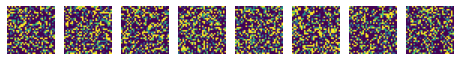

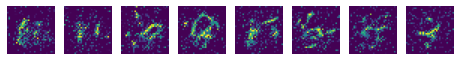

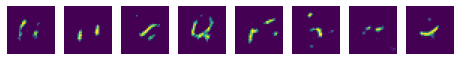

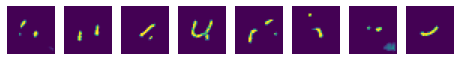

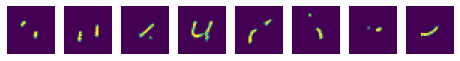

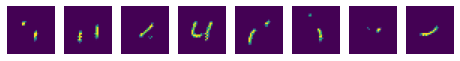

In [7]:
torder = (1,1,1,1) if IMG_CHANNEL == 1 else (1,3,1,1)  # tensor order to be able to use plt.imshow()
means = torch.tensor(means_data, device=Device).view(*torder)
stdevs = torch.tensor(stdevs_data, device=Device).view(*torder)

model_unet.eval()
with torch.no_grad():
    current_images = torch.randn((N_SAMPLES, IMG_CHANNEL, IMG_SIZE, IMG_SIZE), device=Device)  # random noise
    plot(torch.clamp(current_images, 0, 1))

    noise_rates = torch.FloatTensor([0.75]*N_SAMPLES).to(Device)
    pred_images = current_images

    for step in range(DIF_STEPS):
        pred_noises = model_unet(pred_images, noise_rates**2)
        pred_images = torch.clamp(pred_images-pred_noises, 0, 1)
        noise_rates *= 0.80
        plot(pred_images*stdevs+means)

### Experiments

We wrap a function around the generation so we can experiment with different settings. We run it once to verify the default values have the same behavior as the original code above.

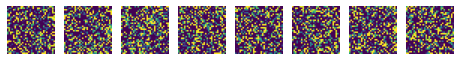

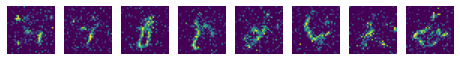

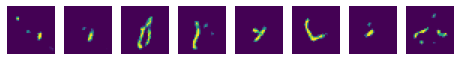

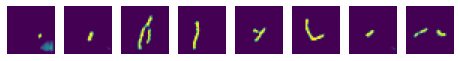

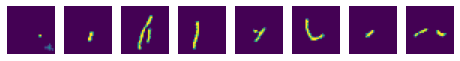

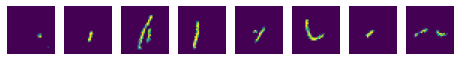

In [8]:

def experimental(dif_steps=DIF_STEPS, noise_factor = 0.75, clamp=True):
    model_unet.eval()
    with torch.no_grad():
        current_images = torch.randn((N_SAMPLES, IMG_CHANNEL, IMG_SIZE, IMG_SIZE), device=Device)  # random noise
        plot(torch.clamp(current_images, 0, 1))

        noise_rates = torch.FloatTensor([noise_factor]*N_SAMPLES).to(Device)
        pred_images = current_images

        for step in range(dif_steps):
            pred_noises = model_unet(pred_images, noise_rates**2)
            if clamp:
                pred_images = torch.clamp(pred_images-pred_noises, 0, 1)
            noise_rates *= 0.80
            plot(pred_images*stdevs+means)

experimental()

### Experiment 1 - Diffusion Steps

We try running with additional diffusion steps

Diff Steps: 5


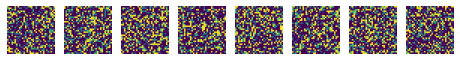

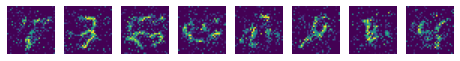

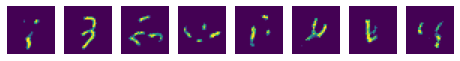

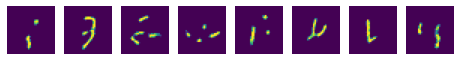

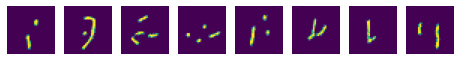

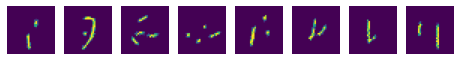

Diff Steps: 10


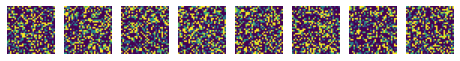

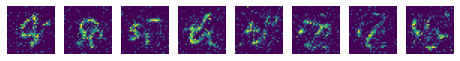

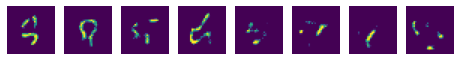

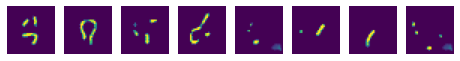

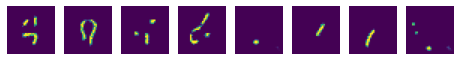

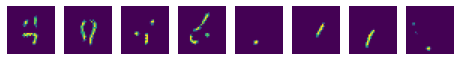

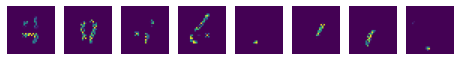

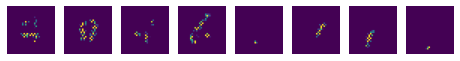

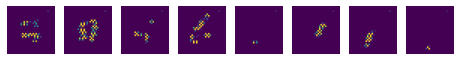

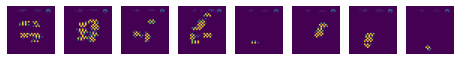

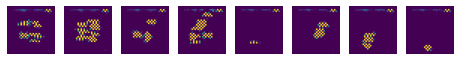

Diff Steps: 20


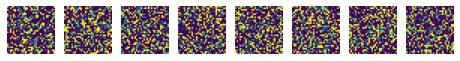

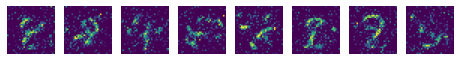

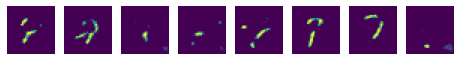

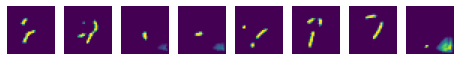

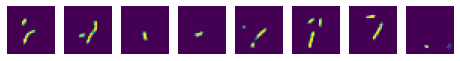

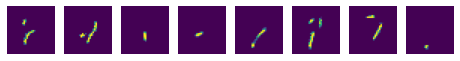

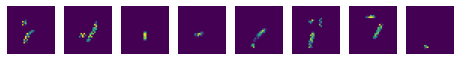

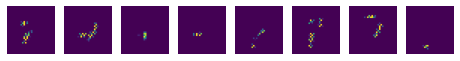

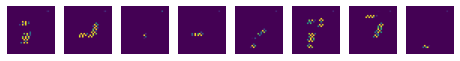

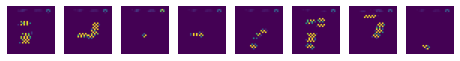

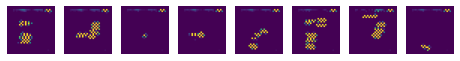

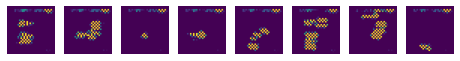

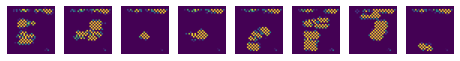

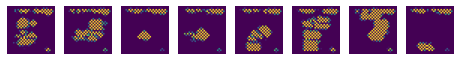

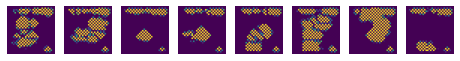

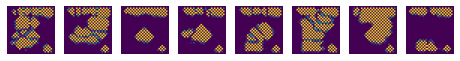

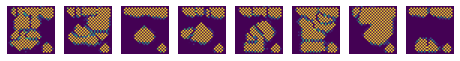

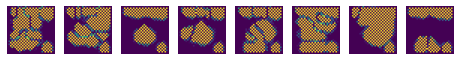

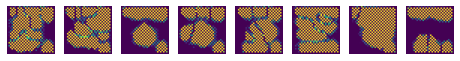

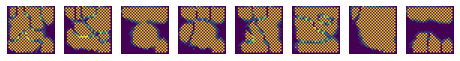

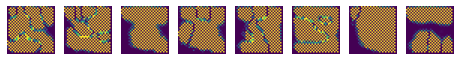

In [9]:
diff_steps_exp = [5, 10, 20]

for diff_steps in diff_steps_exp:
    print(f"Diff Steps: {diff_steps}")
    experimental(dif_steps = diff_steps)

Increasing the number of diffusion steps appears to improve image refinement initially, but at a certain point instability appears due to accumulated approximation error. With 5–10 steps, digits become recognizable and reasonably clean, while at 20 steps the images begin to degrade.

### Experiment 2 - Noise level

We try adjusting the noise levels

Noise Factor: 0.6


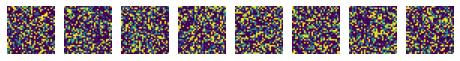

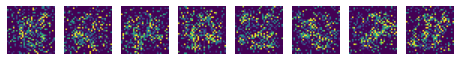

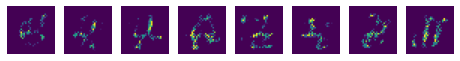

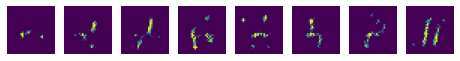

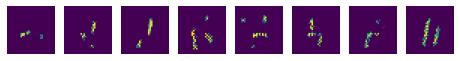

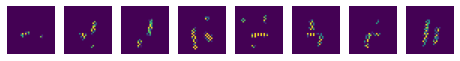

Noise Factor: 0.7


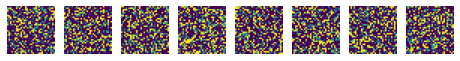

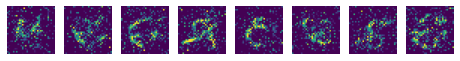

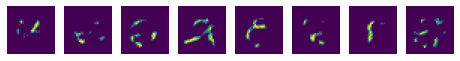

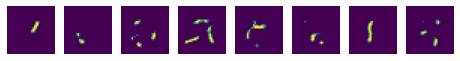

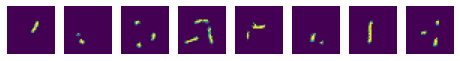

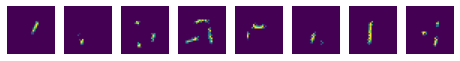

Noise Factor: 0.8


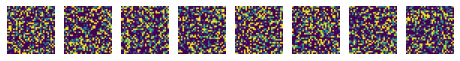

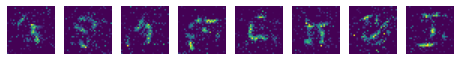

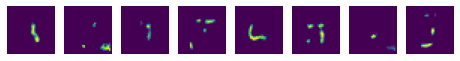

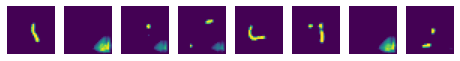

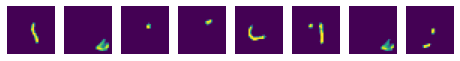

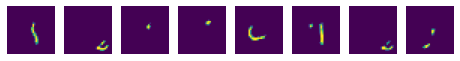

Noise Factor: 0.9


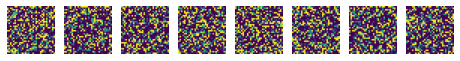

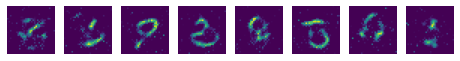

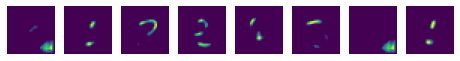

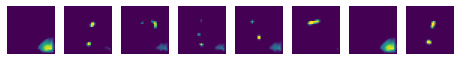

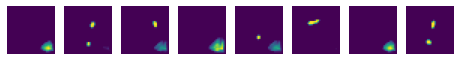

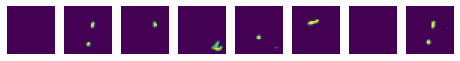

Noise Factor: 1.0


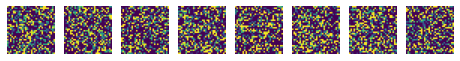

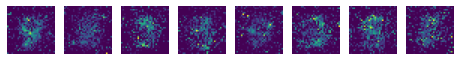

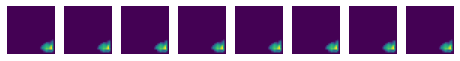

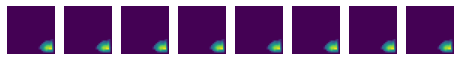

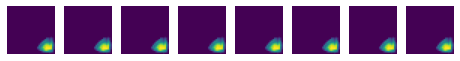

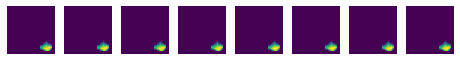

In [10]:
noise_factors = [0.6, 0.7, 0.8, 0.9, 1.0]

for noise_factor in noise_factors:
    print(f"Noise Factor: {noise_factor}")
    experimental(noise_factor=noise_factor)

We see adjusting the initial noise level affects generation quality. Moderate noise levels (0.6–0.8) allow stable denoising and we can still recognize the formations. Higher noise levels (0.9–1.0) make reconstruction more difficult and lead to structural collapse or reduced diversity.

### Experiment 3 - Clamping

We try removing clamping

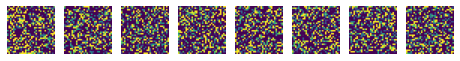

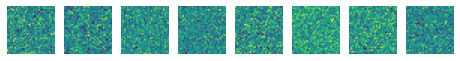

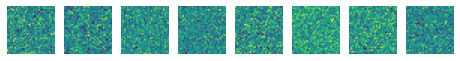

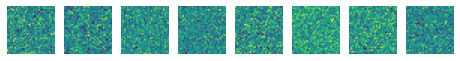

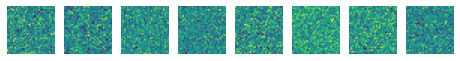

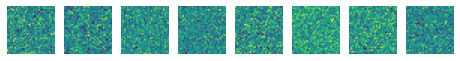

In [11]:
experimental(clamp=False)

Removing clamping causes the denoising process to become unstable because pixel values are no longer constrained to a valid data range. Clamping therefore acts as a stabilizer in our implementation; without it, the image remain "noisy."

## Problem 10

Running the saved diffusion model shows a clear progression from pure Gaussian noise to recognizable imagess over several steps. Early steps give images with coarse structure, while later steps refine edges and reduce background noise. With only five denoising steps, digits are recognizable but slightly rough, indicating that more sampling steps would likely improve sharpness. 

The experiments above showed how sensitive these architectures can be to variance in noise levels, the number of diffusion steps, and how important clamping is for stability. 

In general, I learned that a lot goes into achieving stable, high-quality generation with a U-Net architecture and that diffusion models are iterative refinement processes rather than one-shot generators. Unlike GANs, which produce an image in a single forward pass, diffusion models gradually sculpt structure from noise. While this makes them more stable and interpretable, it also means they are highly dependent on carefully designed noise schedules, scaling factors, and architectural details such as skip connections and residual blocks. Even small changes to these components can noticeably affect output quality.